## Load Champion Model and Frozen Threshold for Drift Monitoring

In [6]:
import pandas as pd
import joblib, json
import numpy as np

# Load data
df = pd.read_csv("../data/creditcard.csv")

# Load frozen model
lgb_model = joblib.load("../models/lgbm_champion.pkl")

# Load frozen threshold
with open("../models/lgbm_threshold.json", "r") as f:
    threshold_data = json.load(f)

lgb_best_threshold = threshold_data["threshold"]
MAX_FPR = threshold_data["max_fpr"]

print("Loaded model + threshold.")
print("Frozen threshold:", lgb_best_threshold)

Loaded model + threshold.
Frozen threshold: 0.014554874923771423


## Create Time-Based Windows for Drift Simulation

In [7]:
# Sort by transaction time
df_sorted = df.sort_values("Time").reset_index(drop=True)

# Split into 4 equal chronological windows
window_size = len(df_sorted) // 4

windows = {
    "Window_1": df_sorted.iloc[0:window_size],
    "Window_2": df_sorted.iloc[window_size:2*window_size],
    "Window_3": df_sorted.iloc[2*window_size:3*window_size],
    "Window_4": df_sorted.iloc[3*window_size:]
}

for name, w in windows.items():
    print(name, "size:", len(w))

Window_1 size: 71201
Window_2 size: 71201
Window_3 size: 71201
Window_4 size: 71204


## Window-Level Performance Monitoring (Frozen Policy)

In [8]:
from sklearn.metrics import confusion_matrix

window_results = []

for name, w in windows.items():
    
    X_w = w.drop("Class", axis=1)
    y_w = w["Class"]
    
    probs = lgb_model.predict_proba(X_w)[:, 1]
    preds = (probs >= lgb_best_threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_w, preds).ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    window_results.append((name, recall, fpr))

for result in window_results:
    print(result)

('Window_1', np.float64(0.9717514124293786), np.float64(0.00023935571074566343))
('Window_2', np.float64(0.9239130434782609), np.float64(5.625166997145228e-05))
('Window_3', np.float64(0.9689922480620154), np.float64(0.00022512381809995497))
('Window_4', np.float64(0.9148936170212766), np.float64(0.00012656447756996203))


## Window-Level Performance Interpretation (Monitoring Layer)

The frozen LightGBM decision policy was evaluated sequentially across four chronological transaction windows to simulate real-time production monitoring.

### Recall Stability

Recall fluctuates between approximately 91% and 97% across windows:

- Window_1: 97.18%
- Window_2: 92.39%
- Window_3: 96.90%
- Window_4: 91.49%

While the model continues to detect the majority of fraud cases, the reduction in recall observed in Window_2 and Window_4 suggests potential early-stage performance drift.

This could be attributable to:

- Evolving fraud patterns
- Behavioural changes in transaction activity
- Data distribution shifts over time

### False Positive Rate Stability

All windows maintain FPR significantly below the 0.2% policy constraint.

This indicates:

- No operational disruption
- No spike in customer friction
- Stable approval behavior

### Preliminary Risk Assessment

The model demonstrates operational stability but shows moderate variation in fraud capture performance.

Further statistical drift analysis (via KL divergence) is required to determine whether these fluctuations are due to natural variation or meaningful data distribution shift requiring intervention.

The next step is to formally quantify feature-level distribution changes relative to the baseline window.

## Statistical Drift Detection (KL Divergence vs Baseline)

In [9]:
from scipy.stats import entropy

baseline = windows["Window_1"].drop("Class", axis=1)

kl_results = {}

for name, w in windows.items():
    if name == "Window_1":
        kl_results[name] = 0.0
        continue
    
    current = w.drop("Class", axis=1)
    
    kl_total = 0
    
    for col in baseline.columns:
        hist_base, bins = np.histogram(baseline[col], bins=50)
        hist_curr, _ = np.histogram(current[col], bins=bins)
        
        # Convert to probabilities
        hist_base = hist_base.astype(float) + 1e-8
        hist_curr = hist_curr.astype(float) + 1e-8
        
        hist_base /= hist_base.sum()
        hist_curr /= hist_curr.sum()
        
        kl_total += entropy(hist_base, hist_curr)
    
    kl_results[name] = kl_total

print("KL Divergence vs Window_1 baseline:\n")
for k, v in kl_results.items():
    print(k + ":", round(v, 6))

KL Divergence vs Window_1 baseline:

Window_1: 0.0
Window_2: 15.13811
Window_3: 2.556028
Window_4: 3.874783


## Drift Alert and Retraining Governance Policy

In [10]:
# --- Governance thresholds ---
RECALL_DROP_THRESHOLD = 0.05   # 5% relative drop
KL_THRESHOLD = 5               # empirical threshold

# Baseline recall (Window_1)
baseline_recall = window_results[0][1]

print("Baseline Recall:", round(baseline_recall, 4))
print("\n--- Drift Alerts ---\n")

alerts = []

for name, recall, fpr in window_results:
    
    recall_drop = baseline_recall - recall
    kl_value = kl_results[name]
    
    drift_flag = False
    
    if recall_drop > RECALL_DROP_THRESHOLD:
        drift_flag = True
    
    if kl_value > KL_THRESHOLD:
        drift_flag = True
    
    print(f"{name}: Recall={round(recall,4)}, KL={round(kl_value,4)}, Drift Alert={drift_flag}")
    
    if drift_flag:
        alerts.append(name)

print("\n--- Retraining Decision ---\n")

if alerts:
    print("Drift detected in:", alerts)
    print("Retraining Recommended.")
else:
    print("No drift alerts triggered. Retraining NOT required.")

Baseline Recall: 0.9718

--- Drift Alerts ---

Window_1: Recall=0.9718, KL=0.0, Drift Alert=False
Window_2: Recall=0.9239, KL=15.1381, Drift Alert=True
Window_3: Recall=0.969, KL=2.556, Drift Alert=False
Window_4: Recall=0.9149, KL=3.8748, Drift Alert=True

--- Retraining Decision ---

Drift detected in: ['Window_2', 'Window_4']
Retraining Recommended.


## Drift Governance Interpretation

Drift monitoring combined both statistical and performance-based triggers:

1. Performance Trigger:
   Recall drop > 5% relative to baseline window.

2. Statistical Trigger:
   KL divergence exceeding threshold of 5.

### Observations

- Window_2 triggered drift due to both significant KL divergence and recall degradation.
- Window_4 triggered drift primarily due to recall degradation.
- Window_3 showed moderate distribution change but stable performance and did not require intervention.

### Governance Decision

Retraining is recommended for windows exhibiting sustained performance degradation and significant distribution shift.

This demonstrates a production-style monitoring framework where model updates are triggered by controlled, policy-driven rules rather than ad-hoc metric inspection.

## Monitoring Dashboard Data Structure

In [11]:
import pandas as pd

monitoring_df = pd.DataFrame({
    "Window": [r[0] for r in window_results],
    "Recall": [r[1] for r in window_results],
    "FPR": [r[2] for r in window_results],
    "KL_Divergence": [kl_results[r[0]] for r in window_results]
})

monitoring_df["Recall_Drop_vs_Baseline"] = monitoring_df["Recall"].iloc[0] - monitoring_df["Recall"]
monitoring_df["Drift_Alert"] = monitoring_df["Window"].isin(alerts)

monitoring_df

,Window,Recall,FPR,KL_Divergence,Recall_Drop_vs_Baseline,Drift_Alert
0,Window_1,0.971751,0.000239,0.000000,0.000000,False
1,Window_2,0.923913,0.000056,15.138110,0.047838,True
2,Window_3,0.968992,0.000225,2.556028,0.002759,False
3,Window_4,0.914894,0.000127,3.874783,0.056858,True


## Recall Monitoring Over Time

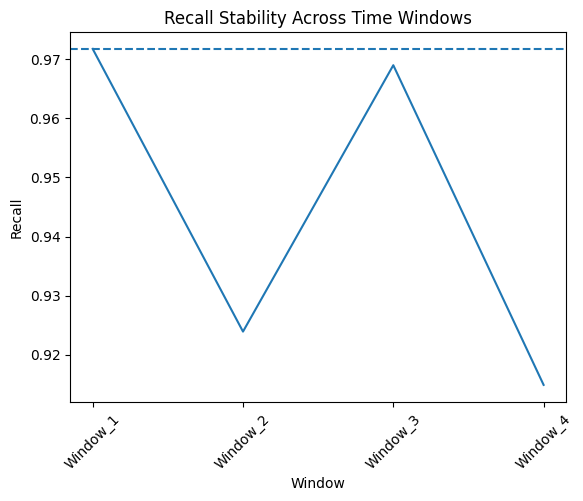

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monitoring_df["Window"], monitoring_df["Recall"])
plt.axhline(y=monitoring_df["Recall"].iloc[0], linestyle='--')
plt.title("Recall Stability Across Time Windows")
plt.xlabel("Window")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.show()

In [13]:
import os
os.makedirs("../reports/figures", exist_ok=True)

plt.savefig("../reports/figures/recall_monitoring.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

## Feature Distribution Drift (KL Divergence)

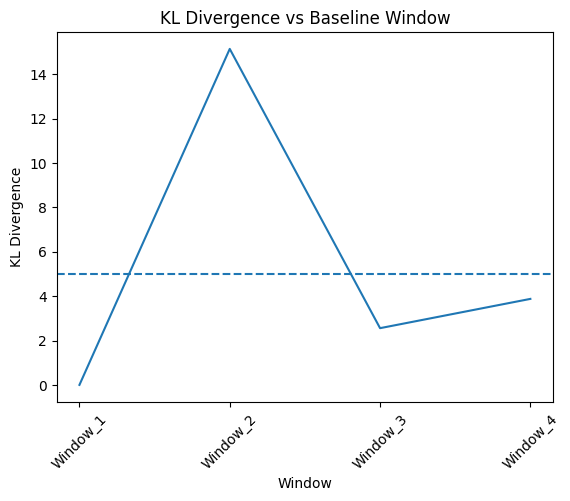

In [14]:
plt.figure()
plt.plot(monitoring_df["Window"], monitoring_df["KL_Divergence"])
plt.axhline(y=5, linestyle='--')  # KL drift threshold
plt.title("KL Divergence vs Baseline Window")
plt.xlabel("Window")
plt.ylabel("KL Divergence")
plt.xticks(rotation=45)
plt.show()

In [15]:
import os
import matplotlib.pyplot as plt

os.makedirs("../reports/figures", exist_ok=True)

plt.savefig("../reports/figures/kl_drift_monitoring.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

## Monitoring Alerts Summary (Production View)

In [9]:
alert_windows = monitoring_df[monitoring_df["Drift_Alert"] == True]

print("MONITORING SUMMARY")
print("Total windows monitored:", len(monitoring_df))
print("Windows with drift alerts:", len(alert_windows))

if len(alert_windows) > 0:
    print("\nALERT WINDOWS:")
    display(alert_windows)
else:
    print("\nNo drift alerts detected.")

MONITORING SUMMARY
Total windows monitored: 4
Windows with drift alerts: 2

ALERT WINDOWS:


,Window,Recall,FPR,KL_Divergence,Recall_Drop_vs_Baseline,Drift_Alert
1,Window_2,0.923913,0.000056,15.138110,0.047838,True
3,Window_4,0.914894,0.000127,3.874783,0.056858,True


## Real-Time Monitoring Architecture (Fraud Operations View)

This section simulates how a bank would monitor a deployed fraud detection system in production.

### Monitoring Signals Tracked

For each sequential time window, the monitoring layer records:

- **Recall** (fraud capture performance)
- **False Positive Rate (FPR)** (customer friction indicator)
- **KL Divergence** (feature distribution drift relative to baseline)
- **Recall drop vs baseline** (performance degradation indicator)
- **Drift alert flag** (governance decision output)

These signals are consolidated into a monitoring table (dashboard-ready) and visualized to support operational oversight.

### Alert Logic (Governance)

A drift alert is triggered if:

- Recall drops beyond policy threshold, and/or
- KL divergence exceeds drift threshold

This dual-trigger approach reflects real-world fraud monitoring practice:
- statistical drift may occur without immediate performance loss
- performance decay may signal model risk even without severe distribution shift

### Operational Outcome

The monitoring summary highlights time windows where model behaviour deviates from baseline expectations.  
These alerts provide a controlled basis for initiating:

- fraud analyst investigation
- model performance review
- retraining pipeline activation (if sustained)

### Business Value

This monitoring architecture ensures the fraud system remains:

- **drift-aware**
- **policy controlled**
- **operationally stable**
- **ready for retraining decisions**

This transforms the project from a static fraud classifier into a production-oriented fraud risk management framework.